In [11]:
import utils as utils
import NeuralNet
from Hyperparams import Hyperparams as hp
import torch.optim as optim
import torch
from IPython.display import Audio

In [12]:
neuralNet = utils.NeuralNetwork(
                                neural_net=NeuralNet.DenoisingNet(),
                                optimizer=optim.Adam,
                                loss_fn = torch.nn.MSELoss(),
                                load_model_path="checkPoint/checkpoint_epoch_41.pt"
)

Using device: cuda


In [13]:
VCTK_PATH = "dataset/clear"
# VCTK_PATH = "dataset/clear/"
DEMAND_PATH = "dataset/noise"

In [14]:
dataset = utils.AudioDenoisingDataset(DEMAND_PATH, VCTK_PATH)

len(self.clean_files) = 17884
len(self.noisy_files) = 80


In [15]:
mix_spector, clean_spector, noisy_spector, clean_audio, noisy_audio, mix_audio =  dataset.get_example()

In [16]:
Audio(mix_audio, rate=hp.sr)

In [17]:
prediction_stft, prediction_signal = neuralNet.get_result_from_model(mix_spector[1])

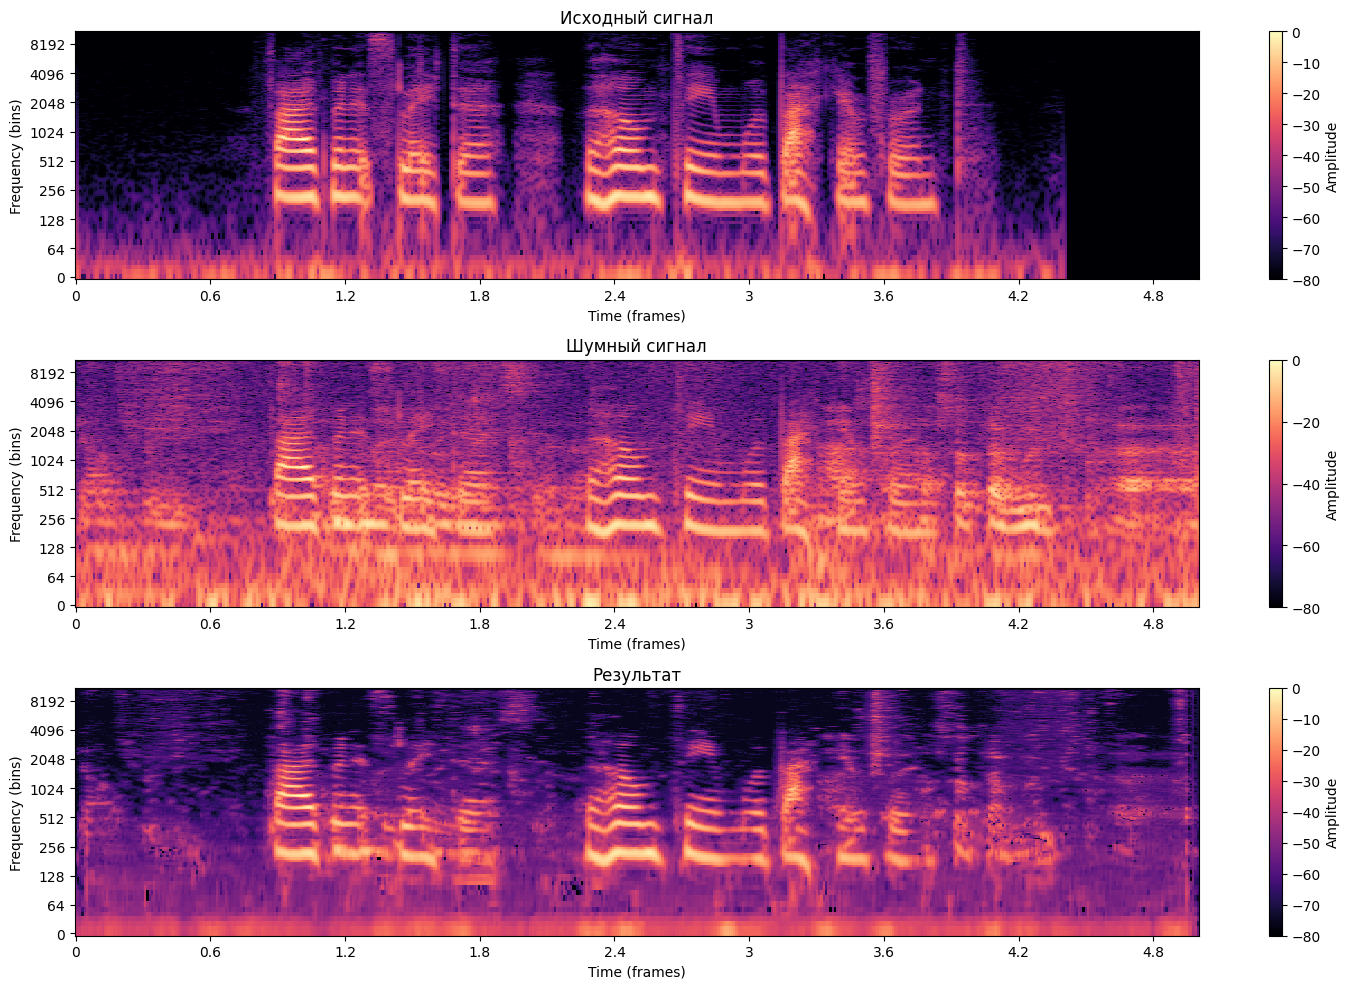

In [18]:
dataset.draw_spectogram((clean_spector[1], "Исходный сигнал"), (mix_spector[1], "Шумный сигнал"),  (prediction_stft, "Результат"))

In [19]:
Audio(clean_audio, rate=hp.sr)

In [20]:
Audio(prediction_signal, rate=hp.sr)